<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Variational Autoencoder From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
Same encoder and decoder as before, two changes. The encoder outputs a mean and a spread instead of a point, and the loss gets a KL term that pulls those distributions towards a standard normal. Writing the loss out by hand since that is where the actual idea lives.
</div>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

torch.manual_seed(0)

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
X = torch.tensor(mnist.data[:10000] / 255.0, dtype=torch.float32)
y = mnist.target[:10000].astype(int)
print("data :", X.shape)

data : torch.Size([10000, 784])


## the encoder outputs two things

for a latent of size L the encoder produces `2L` numbers, the first L are the means and the next L are the log variances. log variance is used instead of variance so that the network can output any number and `exp` makes it positive.

In [2]:
L = 16

encoder = nn.Sequential(
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 2 * L)                 # mu and logvar together
)

decoder = nn.Sequential(
    nn.Linear(L, 256), nn.ReLU(),
    nn.Linear(256, 784), nn.Sigmoid()
)

def encode(x):
    h = encoder(x)
    mu, logvar = h.chunk(2, dim=1)
    return mu, logvar

mu, logvar = encode(X[:4])
print("mu     :", tuple(mu.shape))
print("logvar :", tuple(logvar.shape))
print("so image 0 is a cloud centred at", np.round(mu[0][:4].detach().numpy(), 2), "...")

mu     : (4, 16)
logvar : (4, 16)
so image 0 is a cloud centred at [-0.02  0.02 -0.12  0.04] ...


## the reparameterization trick

the obvious thing is to sample `z` from `N(mu, sigma)` directly. that breaks backprop, you cannot differentiate through a random draw.

the trick is to move the randomness outside:

```
z = mu + sigma * epsilon        where epsilon ~ N(0,1)
```

now the random part is `epsilon` wich has no parameters, and `mu` and `sigma` are reached by plain multiplication and addition, so gradients flow through them normally.

In [3]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)         # logvar to standard deviation
    eps = torch.randn_like(std)           # the only random thing, no gradient needed
    return mu + std * eps

z = reparameterize(mu, logvar)
print("z :", tuple(z.shape))
print("two draws for the same image are diffrent :")
print(" ", np.round(reparameterize(mu, logvar)[0][:5].detach().numpy(), 3))
print(" ", np.round(reparameterize(mu, logvar)[0][:5].detach().numpy(), 3))

z : (4, 16)
two draws for the same image are diffrent :
  [-2.556 -0.509  0.643 -1.666  0.008]
  [-0.805  0.818  2.773  0.111  1.667]


## the loss, two parts

**reconstruction** : did the output match the input. using binary cross entropy per pixel because mnist pixels sit between 0 and 1.

**KL divergence** : how far is the cloud `N(mu, sigma)` from `N(0,1)`. for two gaussians this has a closed form and comes out as one line:

```
KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
```

reading it, the term pushes `mu` toward 0 and `logvar` toward 0 (so sigma toward 1). that is exactly the pull that packs everything around the origin.

In [13]:
def vae_loss(out, target, mu, logvar):
    n = len(target)
    recon = F.binary_cross_entropy(out, target, reduction='sum') / n
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / n
    return recon, kl

checking that the KL term behaves the way i just claimed, before training anything.

In [5]:
def kl_of(mu_val, logvar_val):
    mu_t = torch.full((1,1), mu_val)
    lv_t = torch.full((1,1), logvar_val)
    return (-0.5 * torch.sum(1 + lv_t - mu_t.pow(2) - lv_t.exp())).item()

print("mu=0, sigma=1   (matches the prior) :", round(kl_of(0.0, 0.0), 4))
print("mu=3, sigma=1   (shifted away)      :", round(kl_of(3.0, 0.0), 4))
print("mu=0, sigma=0.1 (too narrow)        :", round(kl_of(0.0, -4.6), 4))
print("mu=0, sigma=5   (too wide)          :", round(kl_of(0.0, 3.2), 4))

mu=0, sigma=1   (matches the prior) : -0.0
mu=3, sigma=1   (shifted away)      : 4.5
mu=0, sigma=0.1 (too narrow)        : 1.805
mu=0, sigma=5   (too wide)          : 10.1663


zero exactly when the cloud is already `N(0,1)` and positive otherwise, in both directions. so it penalises drifting away **and** collapsing to a point.

## training

In [6]:
params = list(encoder.parameters()) + list(decoder.parameters())
opt = torch.optim.Adam(params, lr=1e-3)

hist_recon, hist_kl = [], []

for epoch in range(60):
    perm = torch.randperm(len(X))
    r_tot, k_tot, batches = 0, 0, 0

    for i in range(0, len(X), 256):
        xb = X[perm[i:i+256]]

        mu, logvar = encode(xb)
        z = reparameterize(mu, logvar)
        out = decoder(z)

        recon, kl = vae_loss(out, xb, mu, logvar)
        loss = recon + kl

        opt.zero_grad(); loss.backward(); opt.step()
        r_tot += recon.item(); k_tot += kl.item(); batches += 1

    hist_recon.append(r_tot / batches)
    hist_kl.append(k_tot / batches)
    if epoch % 15 == 0:
        print("epoch", str(epoch).rjust(2), " recon", round(hist_recon[-1], 2), " kl", round(hist_kl[-1], 2))

epoch  0  recon 294.77  kl 12.74


epoch 15  recon 104.24  kl 20.41


epoch 30  recon 92.7  kl 21.98


epoch 45  recon 88.76  kl 22.49


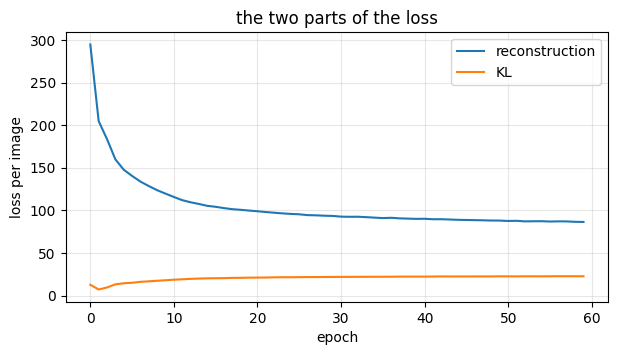

final recon 86.46  final kl 22.69


In [7]:
plt.figure(figsize=(7,3.5))
plt.plot(hist_recon, label='reconstruction')
plt.plot(hist_kl, label='KL')
plt.xlabel('epoch'); plt.ylabel('loss per image'); plt.legend(); plt.grid(alpha=.3)
plt.title('the two parts of the loss')
plt.show()

print("final recon", round(hist_recon[-1], 2), " final kl", round(hist_kl[-1], 2))

the KL rises at the start and then settles. that makes sense, at the beginning the encoder is happy to sit at the prior (KL near 0) and rebuilds badly, then it spends KL budget to move the clouds apart so that diffrent digits can be told apart.

## reconstructions

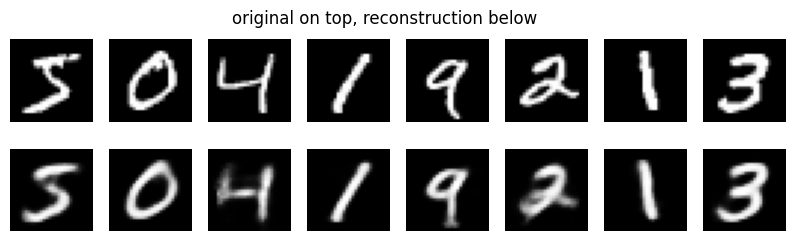

In [8]:
with torch.no_grad():
    mu, logvar = encode(X[:8])
    rebuilt = decoder(mu)                 # using the mean, no sampling, for a clean picture

fig, ax = plt.subplots(2, 8, figsize=(10,2.6))
for i in range(8):
    ax[0,i].imshow(X[i].reshape(28,28), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(rebuilt[i].reshape(28,28), cmap='gray'); ax[1,i].axis('off')
plt.suptitle('original on top, reconstruction below')
plt.show()

## the part that actually matters, sampling

no inspecting the model, no guessing a scale. just draw from `N(0,1)`, wich is what the KL term trained the space to look like.

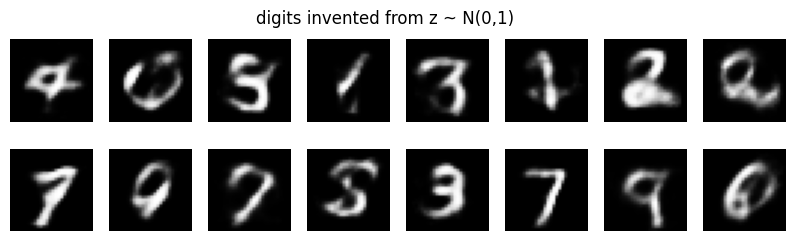

In [10]:
torch.manual_seed(7)
with torch.no_grad():
    samples = decoder(torch.randn(16, L))

fig, ax = plt.subplots(2, 8, figsize=(10,2.6))
for i in range(16):
    ax[i//8, i%8].imshow(samples[i].reshape(28,28), cmap='gray')
    ax[i//8, i%8].axis('off')
plt.suptitle('digits invented from z ~ N(0,1)')
plt.show()

blurry, but they are digits, and there is a proper variety of them instead of the pile of 9s the plain autoencoder gave.

the blurriness is a real property of VAEs, not a bug in my code. the reconstruction loss is per pixel, so when the model is unsure between a 3 and an 8 the safest thing is to output the average of both, wich looks like a smudge. GANs in the next folder attack exactly this.

## did the latent space really become normal

mean of the codes  : 0.009  (target 0)
std  of the codes  : 1.038  (target near 1)
average sigma      : 0.272


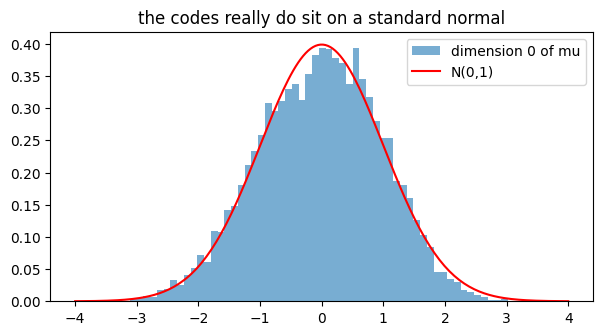

In [11]:
with torch.no_grad():
    mu_all, logvar_all = encode(X)

print("mean of the codes  :", round(mu_all.mean().item(), 3), " (target 0)")
print("std  of the codes  :", round(mu_all.std().item(), 3), " (target near 1)")
print("average sigma      :", round(torch.exp(0.5*logvar_all).mean().item(), 3))

plt.figure(figsize=(7,3.5))
plt.hist(mu_all[:,0].numpy(), bins=60, alpha=.6, density=True, label='dimension 0 of mu')
xs = np.linspace(-4,4,200)
plt.plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), 'r', label='N(0,1)')
plt.legend(); plt.title('the codes really do sit on a standard normal')
plt.show()

### what i learned

- the encoder returning a distribution instead of a point is the whole idea, and the reparameterization trick is what keeps it trainable
- the KL formula is one line and it is zero exactly at `N(0,1)`, i checked that before training rather than trusting it
- after training i can sample without knowing anything about the trained model, thats the difference from Day 47
- samples are blurry because a per pixel loss averages the options it cannot decide between
- the KL going up early and then flattening was the interesting bit, the model spends KL only when reconstruction pays for it